In [61]:
%load_ext autoreload
%autoreload 2
from lotka_voltera_revised import simulate, integrate
#from lotka_voltera import simulate#integrate
import numpy as np

import sys
sys.path.insert(0, "/Users/kjungeum/PycharmProjects/BGAN/BGAN/")
from _data.dataset import CustomDataset,infinite_loader
from torch.utils.data import Dataset, DataLoader
N_size = 500 #1000000
mini_bath_size = 100 #0000
!pwd

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
/Users/kjungeum/PycharmProjects/BGAN/BGAN/_data


In [24]:
np_random = np.random.RandomState(42)
Thetas, X = [],[]
for i in range(int(N_size/mini_bath_size)):
    print(i)
    theta, x = simulate(batch_size = mini_bath_size, np_random=np_random)

    Thetas.append(theta)
    X.append(x)
Thetas_mat = np.concatenate(Thetas, axis=0)
X_mat = np.concatenate(X, axis=0)
np.save('Thetas_mat.npy', Thetas_mat)
np.save('X_mat.npy', X_mat)

0
1
2
3
4


In [25]:
np_random = np.random.RandomState(42)
Thetas, X = [],[]
for i in range(int(N_size/mini_bath_size)):
    print(i)
    theta, x = simulate(batch_size = mini_bath_size, n_iid = 5, np_random=np_random)
    Thetas.append(theta)
    X.append(x)
Thetas_mat = np.concatenate(Thetas, axis=0)
X_mat = np.concatenate(X, axis=0)
np.save('Thetas_mat_iid.npy', Thetas_mat)
np.save('X_mat_iid.npy', X_mat)

0
1
2
3
4


In [27]:
Thetas_mat.shape,X_mat.shape

((500, 4), (500, 5, 3, 201))

In [55]:
datapath = "/Users/kjungeum/PycharmProjects/BGAN/BGAN/_data/"

In [56]:
Thetas_mat = np.load(datapath+'/Thetas_mat.npy')
X_mat = np.load(datapath+'/X_mat.npy')

In [60]:
dataset = CustomDataset(Thetas_mat, X_mat)
data_loader = DataLoader(dataset, batch_size=100, shuffle=True)


# Create an instance of the loader
loader = infinite_loader(data_loader)

# Loop to extract batches
for i in range(10):  # Fetch 10 batches
    x_batch, y_batch = next(loader)
    print(f"Batch {i + 1}:")
    print(f"x_batch shape: {x_batch.shape}, y_batch shape: {y_batch.shape}")


Batch 1:
x_batch shape: torch.Size([100, 4]), y_batch shape: torch.Size([100, 1, 3, 201])
Batch 2:
x_batch shape: torch.Size([100, 4]), y_batch shape: torch.Size([100, 1, 3, 201])
Batch 3:
x_batch shape: torch.Size([100, 4]), y_batch shape: torch.Size([100, 1, 3, 201])
Batch 4:
x_batch shape: torch.Size([100, 4]), y_batch shape: torch.Size([100, 1, 3, 201])
Batch 5:
x_batch shape: torch.Size([100, 4]), y_batch shape: torch.Size([100, 1, 3, 201])
Batch 6:
x_batch shape: torch.Size([100, 4]), y_batch shape: torch.Size([100, 1, 3, 201])
Batch 7:
x_batch shape: torch.Size([100, 4]), y_batch shape: torch.Size([100, 1, 3, 201])
Batch 8:
x_batch shape: torch.Size([100, 4]), y_batch shape: torch.Size([100, 1, 3, 201])
Batch 9:
x_batch shape: torch.Size([100, 4]), y_batch shape: torch.Size([100, 1, 3, 201])
Batch 10:
x_batch shape: torch.Size([100, 4]), y_batch shape: torch.Size([100, 1, 3, 201])


In [44]:
def infinite_loader(self=None):
    while True:
        for x, y in enumerate(DataLoader):
            yield (x, y)
loader = infinite_loader()


In [45]:
for i in range(10):  # Loop through values
    x, y = next(loader)
    print(x, y)



TypeError: 'type' object is not iterable

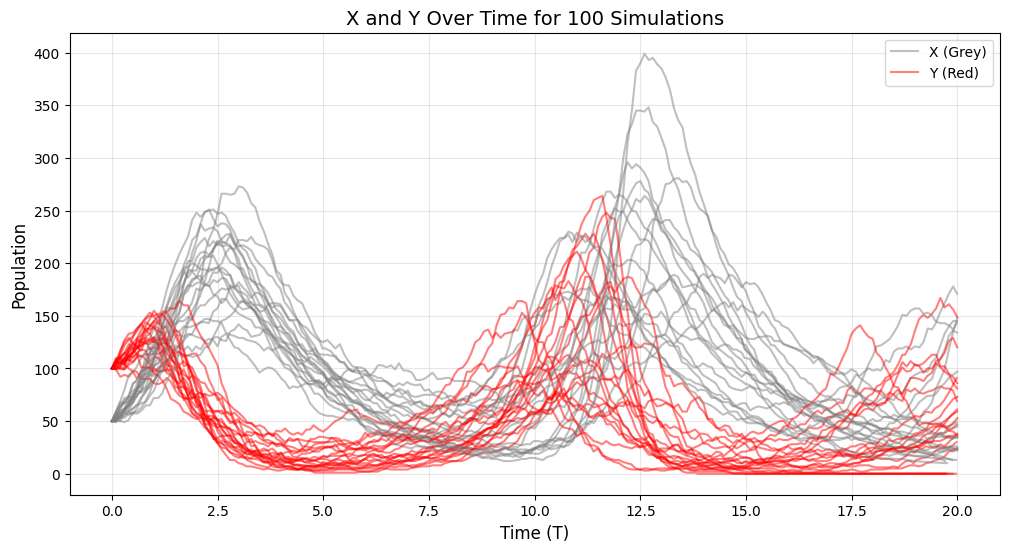

In [39]:

# Assuming `data` is already defined
plot_simulations(data)


In [25]:
import matplotlib.pyplot as plt


# Assuming `data` is a NumPy array of shape (100, 3, 201)
def plot_simulations(data):
    plt.figure(figsize=(12, 6))

    # Loop through each simulation (each "instance" among the 100 simulations)
    for i in range(data.shape[0]):
        T = data[i, 2, :]  # Extract the time points T (201 points for simulation i)
        X = data[i, 0, :]  # Extract the X values (201 points for simulation i)
        Y = data[i, 1, :]  # Extract the Y values (201 points for simulation i)

        # Plot X (red line) and Y (grey line) for this simulation
        plt.plot(T, X, color='grey', alpha=0.5, label='X (Grey)' if i == 0 else "")  # Add label only once
        plt.plot(T, Y, color='red', alpha=0.5, label='Y (Red)' if i == 0 else "")  # Add label only once

    # Add labels, legend, and title
    plt.xlabel("Time (T)", fontsize=12)
    plt.ylabel("Population", fontsize=12)
    plt.title("X and Y Over Time for 100 Simulations", fontsize=14)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


In [59]:
import numpy as np
a0=np.repeat(0.01,4)
b0=np.repeat(0.2,4)
c0=np.repeat(1,4)
d0=np.repeat(0.01,4)
x0=100
y0=50
timestep=0.1
n_steps=200
np_random = np.random.RandomState(1234)
b_size = len(a0)


In [52]:

# Return result: (batch_size x 3 x len(time_discrete))
return np.stack((X_final, Y_final, T_final), axis=1)


In [54]:
np.where(~spoils, np_random.exponential(1 / rate, size=b_size), 0)

array([0.        , 0.00035432, 0.0041375 , 0.00101722])

In [40]:
x_new, y_new

(array([103., 103., 103., 103.], dtype=float32),
 array([50., 50., 50., 50.], dtype=float32))

In [ ]:

# Stack results into arrays (X, Y, times)
X = np.stack(X, axis=0)
Y = np.stack(Y, axis=0)
times = np.stack(times, axis=0)

# Impute values to match `time_discrete`
indices = np.searchsorted(times.T, time_discrete, side="right") - 1  # Batch-wise searchsorted
indices = np.clip(indices, 0, len(times) - 1)  # Ensure indices are within bounds

X_final = np.take_along_axis(X, indices.T, axis=0)
Y_final = np.take_along_axis(Y, indices.T, axis=0)
T_final = np.take_along_axis(times, indices.T, axis=0)

# Return result: (batch_size x 3 x len(time_discrete))
return np.stack((X_final, Y_final, T_final), axis=1)


In [27]:
theta, x = simulate()
theta.shape, x.shape

((100, 4), (100, 1, 3, 201))

In [19]:
theta, x = simulate()
theta.shape, x.shape

((100, 4), (100, 1, 2, 201))

In [63]:
import numpy as np
import random

In [64]:
#thetas = [1,0.01,0.5, 0.01]
thetas = [0.01, 0.2, 1, 0.01]
Xinit, Yinit = 50,100
time_discrete = np.arange(0, 20.1, 0.1)


In [65]:

X = [Xinit]
Y = [Yinit]
times = [0]

spoil = False
i = 0
nstop = 20000

while not spoil and times[i] <= max(time_discrete) and i < nstop:
    i += 1

    rates = [
        thetas[0] * X[i - 1] * Y[i - 1],
        thetas[1] * X[i - 1],
        thetas[2] * Y[i - 1],
        thetas[3] * X[i - 1] * Y[i - 1]
    ]
    rate = sum(rates)

    if rate == 0:
        spoil = True
        break

    time = np.random.exponential(1 / rate)
    times.append(times[i - 1] + time)

    action = random.choices(range(1, 5), weights=rates)[0]

    if action == 1:
        X.append(X[i - 1] + 1)
        Y.append(Y[i - 1])
    elif action == 2:
        X.append(X[i - 1] - 1)
        Y.append(Y[i - 1])
    elif action == 3:
        Y.append(Y[i - 1] + 1)
        X.append(X[i - 1])
    elif action == 4:
        Y.append(Y[i - 1] - 1)
        X.append(X[i - 1])

In [66]:
len(Y), len(X)

(1397, 1397)

In [67]:

TT = len(time_discrete)
Xseries = [Xinit] + [0] * (TT - 1)
Yseries = [Yinit] + [0] * (TT - 1)
time_series = [0] + [0] * (TT - 1)

for j in range(1, TT):
    where = max(idx for idx, t in enumerate(times) if t < time_discrete[j])
    Xseries[j] = X[where]
    Yseries[j] = Y[where]
    time_series[j] = times[where]

In [68]:

if any(x == 0 for x in Xseries):
    where = next(i for i, x in enumerate(Xseries) if x == 0)
    Xseries[where:] = [0] * (TT - where)

if any(y == 0 for y in Yseries):
    where = next(i for i, y in enumerate(Yseries) if y == 0)
    Yseries[where:] = [0] * (TT - where)

In [69]:
 where = next(i for i, y in enumerate(Yseries) if y == 0)
 where

75

In [70]:

data = {
    "Xseries": Xseries,
    "Yseries": Yseries,
    "time_series": time_series,
    "X": X,
    "Y": Y,
    "time": times[-1] if times else 0,
    "spoil": spoil
}

In [72]:
data["Yseries"]


[100,
 107,
 116,
 115,
 113,
 117,
 123,
 124,
 127,
 132,
 128,
 124,
 112,
 111,
 105,
 91,
 79,
 75,
 68,
 58,
 59,
 52,
 46,
 42,
 39,
 33,
 25,
 19,
 18,
 15,
 11,
 9,
 9,
 8,
 7,
 3,
 2,
 2,
 2,
 2,
 2,
 3,
 2,
 2,
 2,
 2,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 2,
 2,
 3,
 4,
 3,
 4,
 4,
 4,
 3,
 4,
 2,
 2,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0]

In [73]:
time_series

[0,
 0.08892672913884016,
 0.19983896474549098,
 0.2795305399624447,
 0.398024047355999,
 0.49506376601849755,
 0.5996319881376009,
 0.6993686562153141,
 0.799368348379094,
 0.8971125284124701,
 0.9999528131853486,
 1.0989159981864665,
 1.1996606830964651,
 1.298354108004889,
 1.3959917960146282,
 1.4952577592691187,
 1.59512443250113,
 1.699045698037542,
 1.7980858159819935,
 1.899430699337555,
 1.9952545266702952,
 2.095853414024688,
 2.1971279537764294,
 2.2957966645394894,
 2.3959229137918143,
 2.4957338029809653,
 2.5980812112145597,
 2.699990573867426,
 2.7982558443614356,
 2.885353417568995,
 2.9896575425559444,
 3.083884806472665,
 3.1971727244262813,
 3.2919619021273903,
 3.39178867648724,
 3.4999473667365,
 3.5990704575282044,
 3.6800659342721307,
 3.7974437510440366,
 3.8693502177616774,
 3.953790757436424,
 4.071998409604544,
 4.171333101307846,
 4.293437417579539,
 4.395065060361603,
 4.463005016943171,
 4.590284466922314,
 4.693607318964115,
 4.799509331685117,
 4.8964792

In [91]:
a0 = [1,1,1,1,1]
b0 = [0.01,0.01,0.01,0.01,0.1]
c0 = [0.5,0.5,0.5,0.5,0.5]
d0 = [0.01,0.01,0.01,0.01,0.01]

x0=100
y0=50
timestep=0.1
np_random=None
seed=1234
n_steps=200

X_batch, Y_batch, T_batch = [], [], []
if np_random is None:
    np_random = np.random.RandomState(seed)

for j in range(min(len(a0),len(b0),len(c0),len(d0))):
    thetas = np.array([a0[j],b0[j],c0[j],d0[j]])

    time_discrete = [timestep * i for i in range(n_steps+1)]

    X,Y = [x0], [y0]
    times = [0]

    spoil = False
    i = 0
    nstop = 20000

    while not spoil and times[i] <= max(time_discrete) and i < nstop:
        i += 1

        rates = [
            thetas[0] * X[i - 1] * Y[i - 1],
            thetas[1] * X[i - 1],
            thetas[2] * Y[i - 1],
            thetas[3] * X[i - 1] * Y[i - 1]
        ]
        rate = sum(rates)

        if rate == 0:
            spoil = True
            break

        time = np.random.exponential(1 / rate)
        times.append(times[i - 1] + time)

        action = random.choices(range(1, 5), weights=rates)[0]

        if action == 1:
            X.append(X[i - 1] + 1)
            Y.append(Y[i - 1])
        elif action == 2:
            X.append(X[i - 1] - 1)
            Y.append(Y[i - 1])
        elif action == 3:
            Y.append(Y[i - 1] + 1)
            X.append(X[i - 1])
        elif action == 4:
            Y.append(Y[i - 1] - 1)
            X.append(X[i - 1])

    TT = len(time_discrete)
    Xseries = [x0] + [0] * (TT - 1)
    Yseries = [y0] + [0] * (TT - 1)
    time_series = [0] + [0] * (TT - 1)

    for j in range(1, TT):
        where = max(idx for idx, t in enumerate(times) if t < time_discrete[j])
        Xseries[j] = X[where]
        Yseries[j] = Y[where]
        time_series[j] = times[where]

    if any(x == 0 for x in Xseries):
        where = next(i for i, x in enumerate(Xseries) if x == 0)
        Xseries[where:] = [0] * (TT - where)

    if any(y == 0 for y in Yseries):
        where = next(i for i, y in enumerate(Yseries) if y == 0)
        Yseries[where:] = [0] * (TT - where)

    X_batch.append(Xseries)
    Y_batch.append(Yseries)
    T_batch.append(time_series)

x,y,t = np.row_stack(X_batch),np.row_stack(Y_batch), np.row_stack(T_batch)
return np.stack((x,y,t), axis=0) # len(a0) x 2 x 201

SyntaxError: 'return' outside function (3893232116.py, line 86)

(5, 3, 201)

In [95]:
x=np.row_stack(X_batch)
y=np.row_stack(Y_batch)
z=np.row_stack(T_batch)

x.shape, y.shape, t.shape

((5, 201), (5, 201), (5, 201))

In [88]:
len(X_batch)

5

In [ ]:
미니배치로 합치는 부분만 확인하면 된다.